In [1]:
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import re

In [2]:
import sys, os

# AutomationModule lives in the root of the tidy3d project
sys.path.append(os.path.abspath(r'H:\codes\tidy3d'))
import AutomationModule as AM
tidy3dAPI = os.environ["API_TIDY3D_KEY"]


In [3]:
file = rf"./data/20260918_transmission_data_woodpiles.h5"
data_loaded = AM.read_hdf5_as_dict(file)
data_loaded.keys()

dict_keys(['lambda', 'transmission_data'])

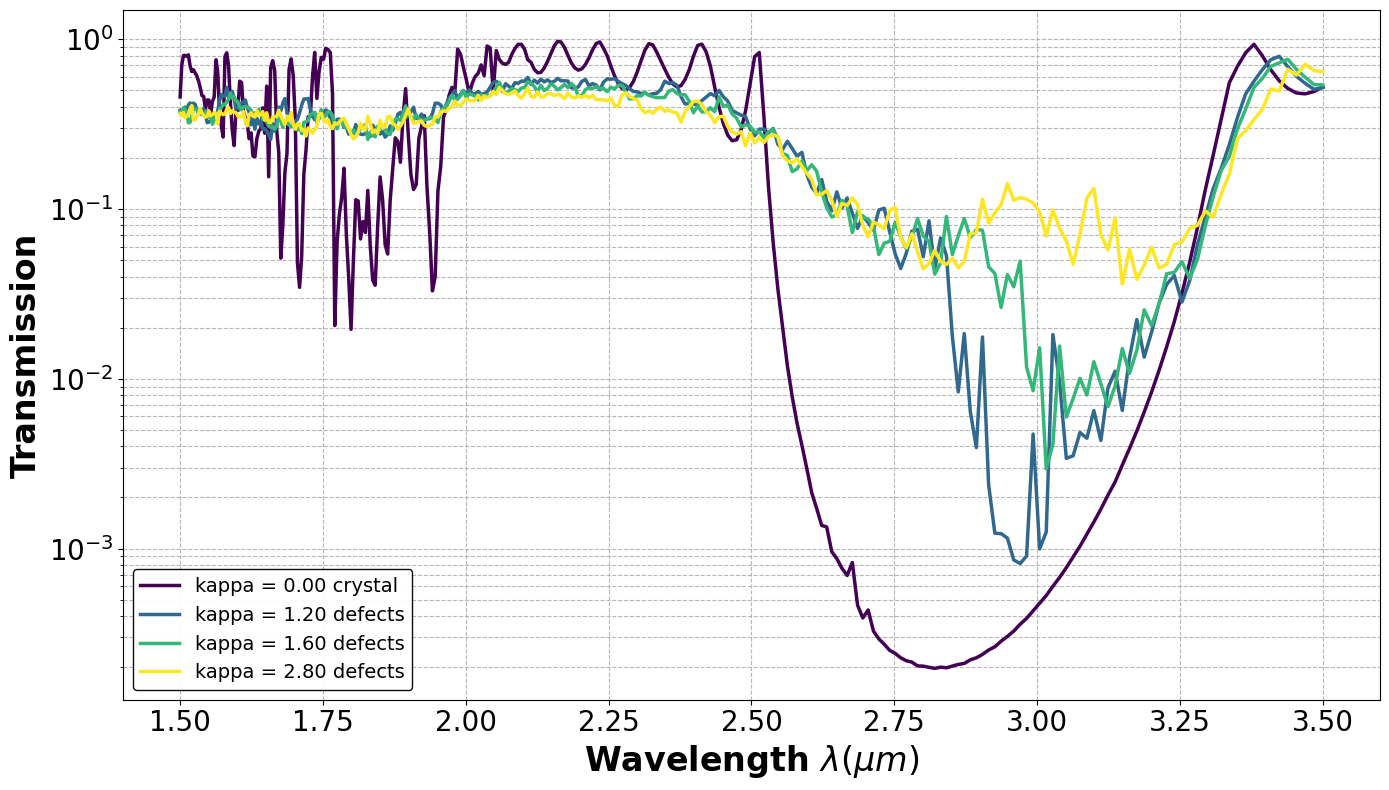

In [4]:
# Improved conference-quality plot
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use a colormap that works well for presentations
colors = plt.cm.viridis(np.linspace(0, 1, len(data_loaded["transmission_data"].keys())))

fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

# Plot data and track what we've added to legend
added_to_legend = set()

for j, item in enumerate(data_loaded["transmission_data"].keys()):
    kappa_value = float(re.search(r'kappa([+-]?\d+(?:\.\d+)?)', item).group(1))
    label = f"kappa = {kappa_value:.2f} {'crystal' if kappa_value ==0 else 'defects'}"
    wavelength = (data_loaded["lambda"]) 
    transmission = data_loaded["transmission_data"][item]['transmission_exit'] 
    
    ax.plot(wavelength, transmission, label=label, color=colors[j], 
           linewidth=2.5)

# Styling for conference
ax.set_yscale("log")
ax.set_xlabel(rf"Wavelength $\lambda(\mu m)$", fontsize=24, fontweight='bold')
ax.set_ylabel("Transmission", fontsize=24, fontweight='bold')

ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=14, framealpha=0.95, edgecolor='black')
# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)

# Add subtle background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()


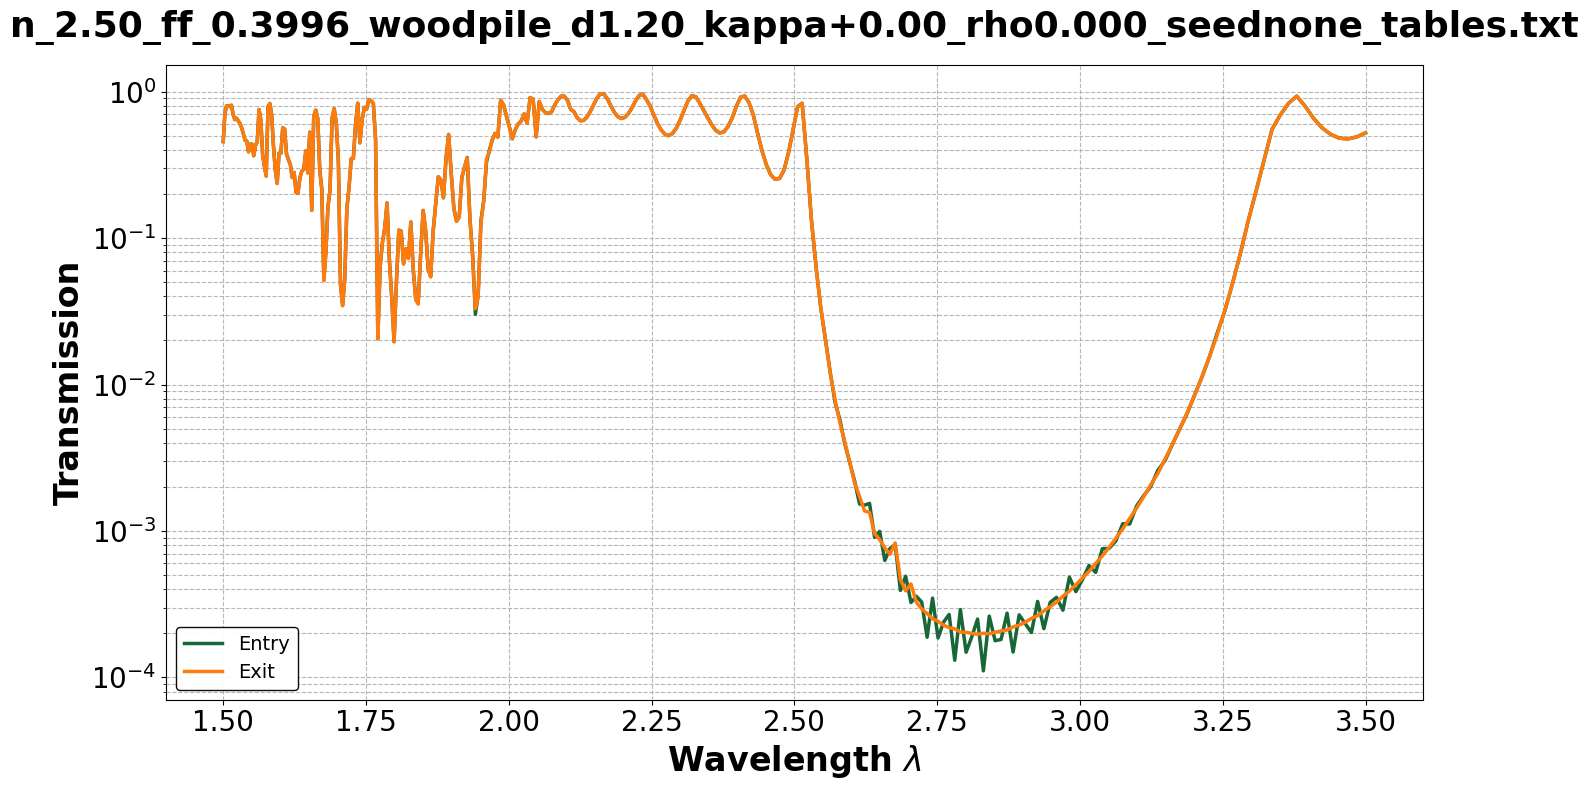

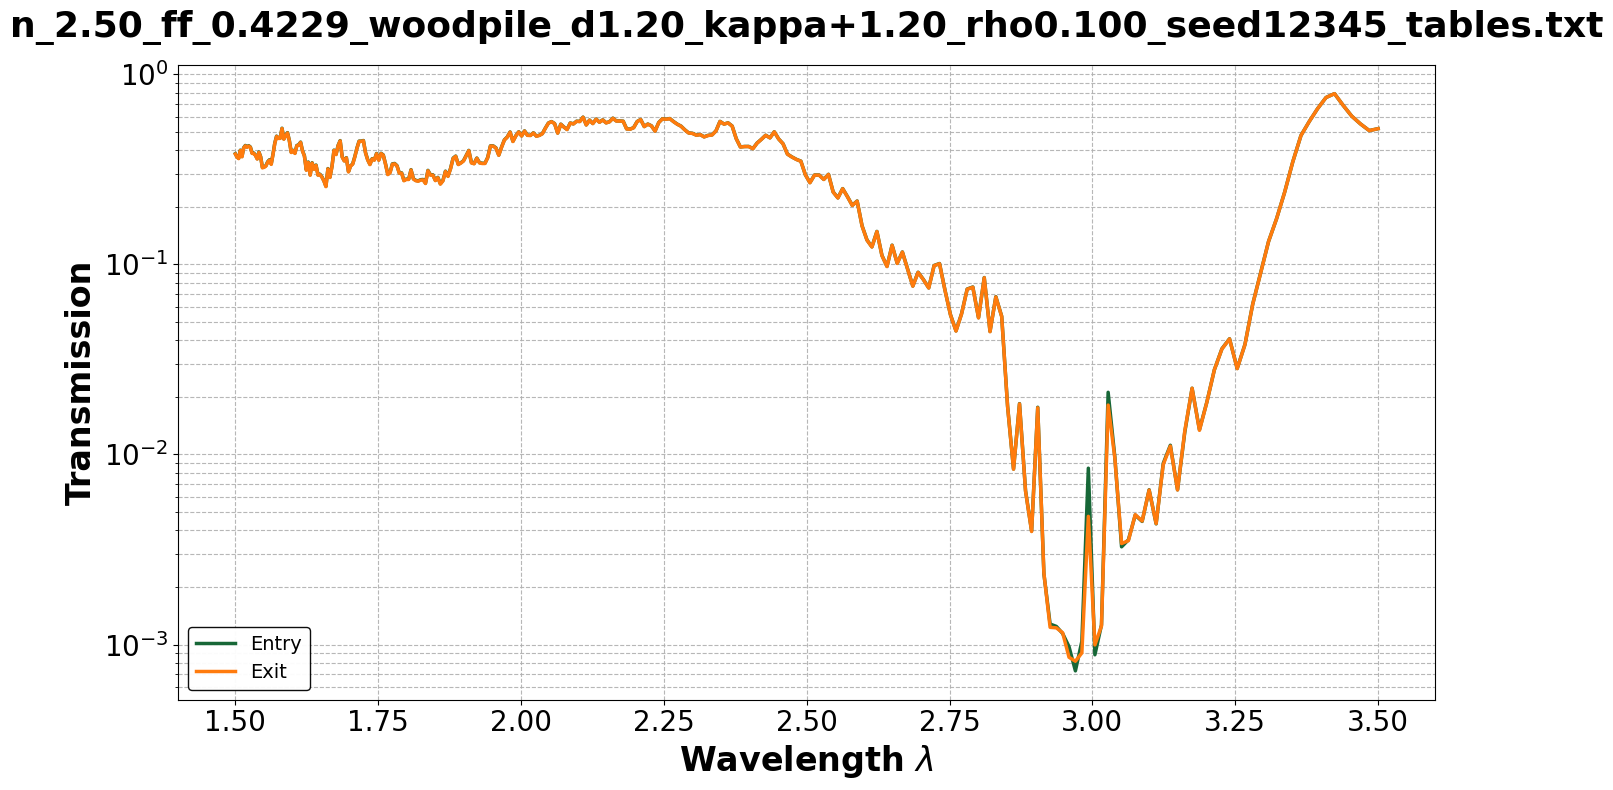

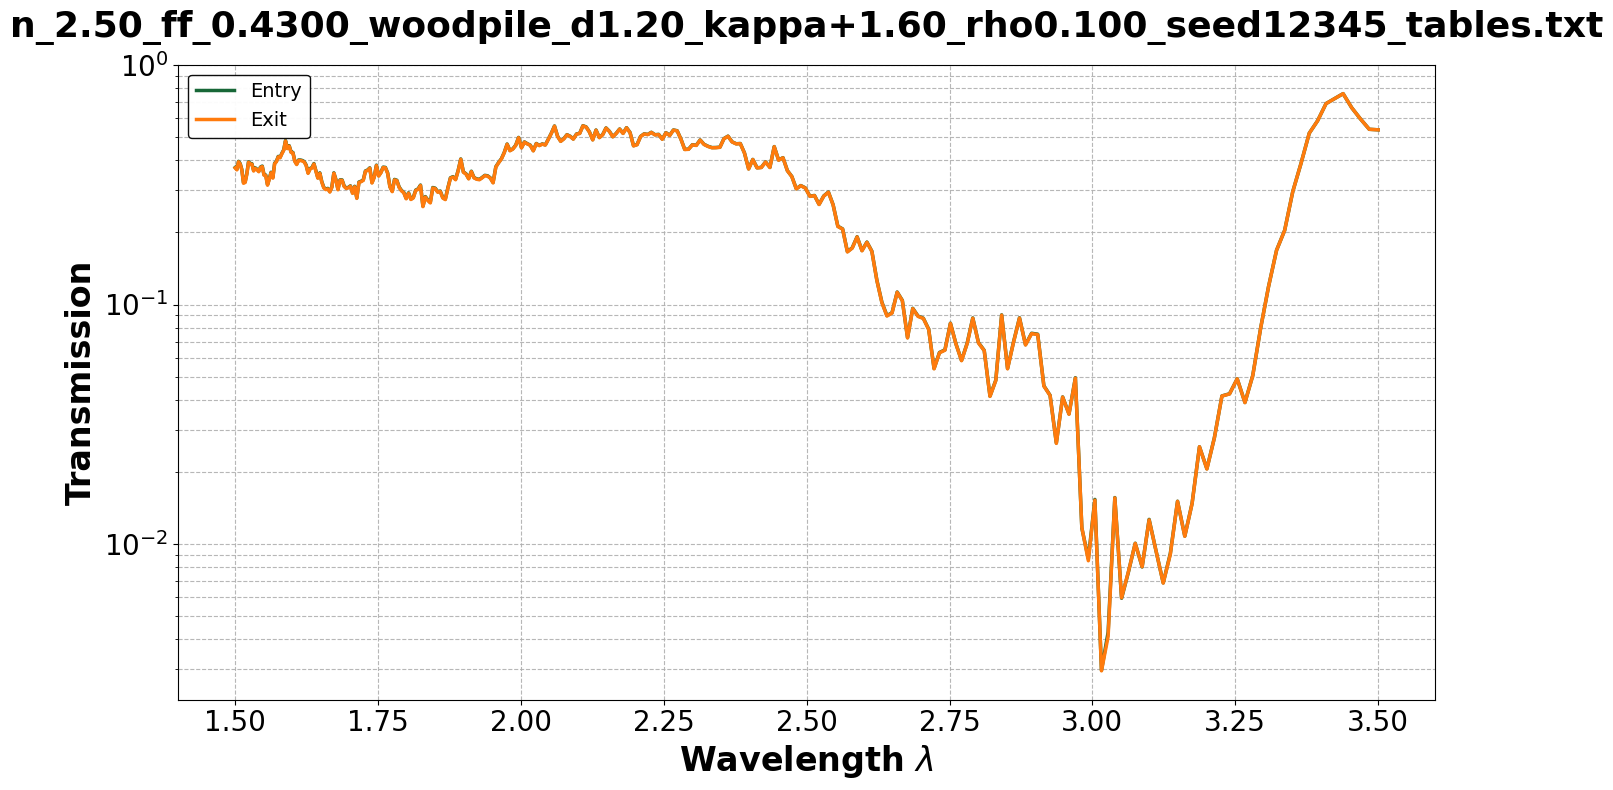

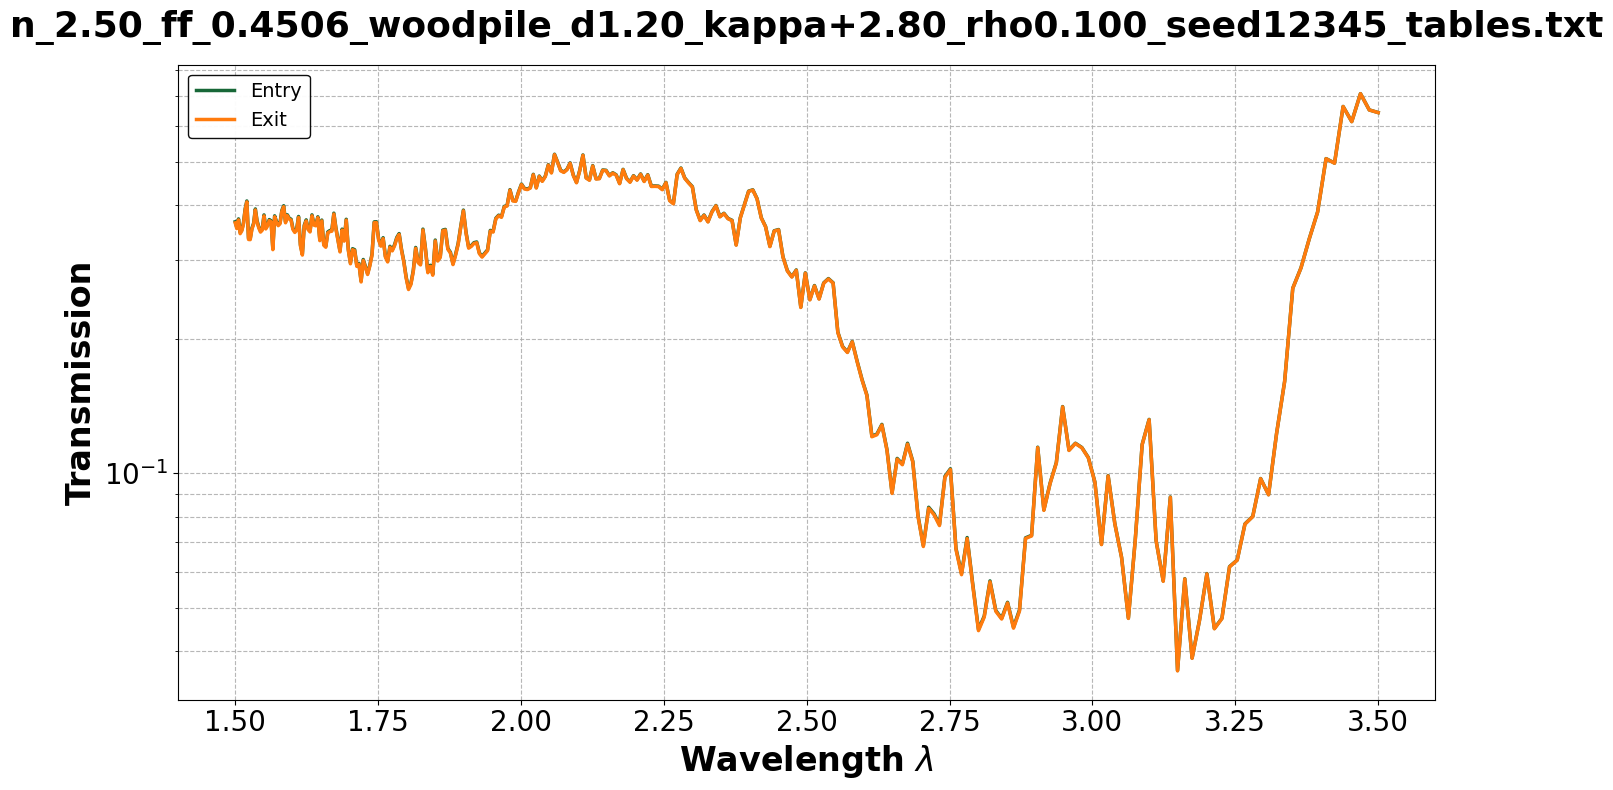

In [5]:
#convergence
# Improved conference-quality plot
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use a colormap that works well for presentations


# Plot data and track what we've added to legend
added_to_legend = set()

for j, item in enumerate(data_loaded["transmission_data"].keys()):
    fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
           
    wavelength = (data_loaded["lambda"]) 
    transmission_exit = data_loaded["transmission_data"][item]['transmission_exit'] 
    transmission_entry = data_loaded["transmission_data"][item]['transmission_entry'] 
    
    ax.plot(wavelength, transmission_entry, label="Entry", 
           linewidth=2.5)
    ax.plot(wavelength, transmission_exit, label="Exit", 
                               linewidth=2.5)

    # Styling for conference
    ax.set_yscale("log")
    ax.set_xlabel(rf"Wavelength $\lambda$", fontsize=24, fontweight='bold')
    ax.set_ylabel("Transmission", fontsize=24, fontweight='bold')
    ax.set_title(item, fontsize=26, fontweight='bold', pad=20)

    ax.grid(True, which="both", alpha=0.9, linestyle='--')
    ax.legend(loc='best', fontsize=14, framealpha=0.95, edgecolor='black')
    # Improve tick label size
    ax.tick_params(axis='both', which='major', labelsize=20)

    # Add subtle background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    plt.tight_layout()
    plt.show()
